In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import math

In [ ]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return 10*len(x) + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def ackley(x):
    return -20*np.exp(-0.2*np.sqrt(np.mean(x**2))) \
           - np.exp(np.mean(np.cos(2*np.pi*x))) + 20 + np.e

def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (x[:-1]-1)**2)

benchmarks = {
    "Sphere": sphere,
    "Rastrigin": rastrigin,
    "Ackley": ackley,
    "Rosenbrock": rosenbrock
}

In [ ]:
POP = 30
DIM = 5
MAX_ITERS = 300
LB = -10
UB = 10
RUNS = 10
EPS = 1e-6

In [ ]:
def PSO(obj):
    start = time.time()

    X = np.random.uniform(LB, UB, (POP, DIM))
    V = np.zeros_like(X)
    pbest = X.copy()
    pbest_val = np.array([obj(x) for x in X])
    gbest = pbest[np.argmin(pbest_val)]
    gbest_val = np.min(pbest_val)

    curve = []

    for t in range(MAX_ITERS):
        w, c1, c2 = 0.7, 1.5, 1.5
        r1, r2 = np.random.rand(), np.random.rand()

        V = w*V + c1*r1*(pbest-X) + c2*r2*(gbest-X)
        X = np.clip(X+V, LB, UB)

        for i in range(POP):
            val = obj(X[i])
            if val < pbest_val[i]:
                pbest_val[i] = val
                pbest[i] = X[i]

        gbest_val = np.min(pbest_val)
        gbest = pbest[np.argmin(pbest_val)]
        curve.append(gbest_val)

    return gbest_val, np.array(curve), time.time()-start

In [ ]:
def GWO(obj):
    start = time.time()

    # Initialize wolf positions
    X = np.random.uniform(LB, UB, (POP, DIM))
    curve = []

    for t in range(MAX_ITERS):

        # Fitness evaluation
        fitness = np.array([obj(x) for x in X])
        idx = np.argsort(fitness)

        # Identify alpha, beta, delta wolves
        alpha = X[idx[0]].copy()
        beta  = X[idx[1]].copy()
        delta = X[idx[2]].copy()

        # Control parameter (linearly decreasing)
        a = 2 - 2 * (t / MAX_ITERS)

        # Position update
        for i in range(POP):
            for d in range(DIM):

                # Alpha influence
                r1, r2 = np.random.rand(), np.random.rand()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha[d] - X[i, d])
                X1 = alpha[d] - A1 * D_alpha

                # Beta influence
                r1, r2 = np.random.rand(), np.random.rand()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta[d] - X[i, d])
                X2 = beta[d] - A2 * D_beta

                # Delta influence
                r1, r2 = np.random.rand(), np.random.rand()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta[d] - X[i, d])
                X3 = delta[d] - A3 * D_delta

                # Final position update (average guidance)
                X[i, d] = (X1 + X2 + X3) / 3

        # Boundary control
        X = np.clip(X, LB, UB)

        # Store best fitness (alpha)
        curve.append(obj(alpha))

    return obj(alpha), np.array(curve), time.time() - start

In [ ]:
def GA(obj):
    start = time.time()

    X = np.random.uniform(LB, UB, (POP, DIM))
    curve = []

    for t in range(MAX_ITERS):
        fitness = np.array([obj(x) for x in X])
        idx = np.argsort(fitness)
        X = X[idx]

        curve.append(fitness[idx[0]])

        parents = X[:POP//2]
        children = []

        for _ in range(POP//2):
            p1, p2 = parents[np.random.randint(len(parents), size=2)]
            cp = np.random.randint(DIM)
            child = np.concatenate([p1[:cp], p2[cp:]])
            if np.random.rand() < 0.1:
                child += np.random.normal(0, 0.1, DIM)
            children.append(child)

        X = np.vstack((parents, children))
        X = np.clip(X, LB, UB)

    return curve[-1], np.array(curve), time.time()-start

In [ ]:
def BA(obj):
    start = time.time()

    Qmin, Qmax = 0, 2
    A, r = 0.5, 0.5

    X = np.random.uniform(LB, UB, (POP, DIM))
    V = np.zeros_like(X)
    Q = np.zeros(POP)

    fitness = np.array([obj(x) for x in X])
    best = X[np.argmin(fitness)]
    best_val = np.min(fitness)

    curve = []

    for t in range(MAX_ITERS):
        for i in range(POP):
            Q[i] = Qmin + (Qmax-Qmin)*np.random.rand()
            V[i] += (X[i]-best)*Q[i]
            X[i] += V[i]

            if np.random.rand() > r:
                X[i] = best + 0.001*np.random.randn(DIM)

            X[i] = np.clip(X[i], LB, UB)
            fnew = obj(X[i])

            if fnew < fitness[i] and np.random.rand() < A:
                fitness[i] = fnew

        best = X[np.argmin(fitness)]
        best_val = np.min(fitness)
        curve.append(best_val)

    return best_val, np.array(curve), time.time()-start

In [ ]:
def FA(obj):
    start = time.time()

    beta0, gamma, alpha = 1, 1, 0.2
    X = np.random.uniform(LB, UB, (POP, DIM))
    curve = []

    for t in range(MAX_ITERS):
        fitness = np.array([obj(x) for x in X])

        for i in range(POP):
            for j in range(POP):
                if fitness[j] < fitness[i]:
                    r = np.linalg.norm(X[i]-X[j])
                    beta = beta0*np.exp(-gamma*r**2)
                    X[i] += beta*(X[j]-X[i]) + alpha*(np.random.rand(DIM)-0.5)

        X = np.clip(X, LB, UB)
        curve.append(np.min(fitness))

    return np.min(fitness), np.array(curve), time.time()-start

In [ ]:
def levy(dim):
    beta = 1.5
    sigma = (math.gamma(1+beta) * math.sin(math.pi*beta/2) /
            (math.gamma((1+beta)/2) * beta * 2**((beta-1)/2)))**(1/beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / (np.abs(v)**(1/beta))

def CS(obj):
    start = time.time()

    pa = 0.25
    X = np.random.uniform(LB, UB, (POP, DIM))
    fitness = np.array([obj(x) for x in X])
    curve = []

    for t in range(MAX_ITERS):
        i = np.random.randint(POP)
        new = X[i] + 0.01*levy(DIM)
        new = np.clip(new, LB, UB)
        fnew = obj(new)

        j = np.random.randint(POP)
        if fnew < fitness[j]:
            X[j] = new
            fitness[j] = fnew

        abandon = np.random.rand(POP) < pa
        X[abandon] = np.random.uniform(LB, UB, (np.sum(abandon), DIM))
        fitness[abandon] = np.array([obj(x) for x in X[abandon]])

        curve.append(np.min(fitness))

    return np.min(fitness), np.array(curve), time.time()-start

In [ ]:
def HS(obj):
    start = time.time()

    HMCR, PAR = 0.9, 0.3
    X = np.random.uniform(LB, UB, (POP, DIM))
    fitness = np.array([obj(x) for x in X])
    curve = []

    for t in range(MAX_ITERS):
        new = np.zeros(DIM)
        for d in range(DIM):
            if np.random.rand() < HMCR:
                new[d] = X[np.random.randint(POP), d]
                if np.random.rand() < PAR:
                    new[d] += 0.01*np.random.randn()
            else:
                new[d] = np.random.uniform(LB, UB)

        new = np.clip(new, LB, UB)
        fnew = obj(new)

        worst = np.argmax(fitness)
        if fnew < fitness[worst]:
            X[worst] = new
            fitness[worst] = fnew

        curve.append(np.min(fitness))

    return np.min(fitness), np.array(curve), time.time()-start

In [ ]:
def SA(obj):
    start = time.time()

    T, Tmin, alpha = 100, 1e-5, 0.95
    x = np.random.uniform(LB, UB, DIM)
    fx = obj(x)
    curve = []

    while T > Tmin:
        x_new = x + 0.1*np.random.randn(DIM)
        x_new = np.clip(x_new, LB, UB)
        f_new = obj(x_new)

        if f_new < fx or np.random.rand() < np.exp(-(f_new-fx)/T):
            x, fx = x_new, f_new

        curve.append(fx)
        T *= alpha

    # ✅ SAFE NORMALIZATION (NO NEGATIVE PAD)
    curve = np.array(curve)

    if len(curve) < MAX_ITERS:
        curve = np.pad(curve, (0, MAX_ITERS-len(curve)), mode='edge')
    else:
        curve = curve[:MAX_ITERS]

    return fx, curve, time.time()-start

In [ ]:
def ACO(obj):
    start = time.time()

    tau = np.ones((POP, DIM))
    X = np.random.uniform(LB, UB, (POP, DIM))
    curve = []

    for t in range(MAX_ITERS):
        for i in range(POP):
            for d in range(DIM):
                X[i,d] = LB + (UB-LB)*np.random.rand()

        fitness = np.array([obj(x) for x in X])
        tau *= 0.9
        tau[np.argmin(fitness)] += 1

        curve.append(np.min(fitness))

    return np.min(fitness), np.array(curve), time.time()-start

In [ ]:
def BBBC(obj):
    start = time.time()

    X = np.random.uniform(LB, UB, (POP, DIM))
    curve = []

    for t in range(MAX_ITERS):
        fitness = np.array([obj(x) for x in X])
        center = np.sum(X / fitness[:,None], axis=0) / np.sum(1/fitness)

        X = center + (UB-LB)*np.random.randn(POP, DIM)/(t+1)
        X = np.clip(X, LB, UB)

        curve.append(np.min(fitness))

    return np.min(fitness), np.array(curve), time.time()-start

In [ ]:
def ABC(obj):
    start = time.time()
    SN = POP
    limit = 100

    X = np.random.uniform(LB, UB, (SN, DIM))
    fit = np.array([obj(x) for x in X])
    trial = np.zeros(SN)
    curve = []

    for _ in range(MAX_ITERS):
        # Employed bees
        for i in range(SN):
            k = np.random.choice([j for j in range(SN) if j != i])
            phi = np.random.uniform(-1,1,DIM)
            v = X[i] + phi*(X[i]-X[k])
            v = np.clip(v, LB, UB)
            fv = obj(v)
            if fv < fit[i]:
                X[i], fit[i], trial[i] = v, fv, 0
            else:
                trial[i] += 1

        # Onlooker bees
        prob = (1/(1+fit)) / np.sum(1/(1+fit))
        for _ in range(SN):
            i = np.random.choice(range(SN), p=prob)
            k = np.random.choice([j for j in range(SN) if j != i])
            phi = np.random.uniform(-1,1,DIM)
            v = X[i] + phi*(X[i]-X[k])
            v = np.clip(v, LB, UB)
            fv = obj(v)
            if fv < fit[i]:
                X[i], fit[i], trial[i] = v, fv, 0
            else:
                trial[i] += 1

        # Scout bees
        for i in range(SN):
            if trial[i] > limit:
                X[i] = np.random.uniform(LB, UB, DIM)
                fit[i] = obj(X[i])
                trial[i] = 0

        curve.append(np.min(fit))

    return np.min(fit), np.array(curve), time.time()-start

In [ ]:
def IPSO(obj):
    start = time.time()
    X = np.random.uniform(LB, UB, (POP, DIM))
    V = np.zeros_like(X)

    pbest = X.copy()
    pfit = np.array([obj(x) for x in X])
    gbest = pbest[np.argmin(pfit)]

    w_max, w_min = 0.9, 0.4
    c1, c2 = 2.0, 2.0
    curve = []

    for t in range(MAX_ITERS):
        w = w_max - (w_max-w_min)*(t/MAX_ITERS)

        for i in range(POP):
            r1, r2 = np.random.rand(), np.random.rand()
            V[i] = w*V[i] + c1*r1*(pbest[i]-X[i]) + c2*r2*(gbest-X[i])
            X[i] = np.clip(X[i] + V[i], LB, UB)

            f = obj(X[i])
            if f < pfit[i]:
                pbest[i], pfit[i] = X[i], f

        gbest = pbest[np.argmin(pfit)]
        curve.append(np.min(pfit))

    return np.min(pfit), np.array(curve), time.time()-start

In [ ]:
algorithms = {
    "PSO": PSO,
    "GA": GA,
    "FA": FA,
    "GWO": GWO,
    "ABC": ABC,
    "IPSO": IPSO,
    "HS": HS,
    "SA": SA,
    "ACO": ACO,
    "BA": BA,
    "CS": CS,
    "BBBC": BBBC
}

results = {}

for fname, f in benchmarks.items():
    results[fname] = {}

    for aname, algo in algorithms.items():
        best_vals, times, curves = [], [], []

        for _ in range(RUNS):
            b, c, t = algo(f)
            best_vals.append(b)
            times.append(t)
            curves.append(c)

        curves = np.array(curves)

        results[fname][aname] = {
    "Best": np.min(best_vals),
    "Mean": np.mean(best_vals),
    "Std": np.std(best_vals),
    "CV": np.std(best_vals) / np.mean(best_vals),
    "BestVals": best_vals,
    "AvgTime": np.mean(times),
    "AvgCurve": np.mean(curves, axis=0)
}

In [ ]:
def reliability_label(cv):
    if cv < 0.1:
        return "Very High"
    elif cv < 0.3:
        return "High"
    elif cv < 0.6:
        return "Medium"
    else:
        return "Low"

In [ ]:
def avg_conv_iter(curve):
    for i in range(1, len(curve)):
        if abs(curve[i] - curve[i-1]) < EPS:
            return i
    return MAX_ITERS

In [ ]:
table = []

for f in results:
    for a in results[f]:
        curve = results[f][a]["AvgCurve"]
        table.append([
            f, a,
            results[f][a]["Best"],
            results[f][a]["Mean"],
            results[f][a]["Std"],
            avg_conv_iter(curve),
            results[f][a]["AvgTime"]
        ])

df = pd.DataFrame(table, columns=[
    "Function","Algorithm","Best","Mean","Std",
    "Avg Convergence Iter","Avg CPU Time (s)"
])

df

,Function,Algorithm,Best,Mean,Std,Avg Convergence Iter,Avg CPU Time (s)
0,Sphere,PSO,6.418060e-27,3.354471e-06,1.003652e-05,91,0.072353
1,Sphere,GA,3.826487e-04,1.763765e-03,1.381889e-03,149,0.188225
2,Sphere,FA,1.278802e+01,4.377857e+01,1.878439e+01,1,2.301589
3,Sphere,GWO,3.631337e-71,6.406520e-67,1.747764e-66,22,0.458238
4,Sphere,ABC,5.143343e-37,5.050240e-35,8.327041e-35,60,1.108593
5,Sphere,IPSO,1.559740e-21,4.650576e-16,1.386838e-15,11,0.281544
6,Sphere,HS,1.986968e-01,1.862253e+00,1.004690e+00,1,0.014012
7,Sphere,SA,2.775145e-02,1.268410e+01,1.473340e+01,300,0.005126
8,Sphere,ACO,2.260841e+01,5.138561e+01,1.660379e+01,300,0.094736
9,Sphere,BA,7.920396e+00,3.438588e+01,1.943756e+01,6,0.187262


In [ ]:
reliability_table = []

for f in results:
    for a in results[f]:
        mean = results[f][a]["Mean"]
        std  = results[f][a]["Std"]
        cv   = results[f][a]["CV"]

        reliability_table.append([
            f, a,
            mean,
            std,
            cv,
            reliability_label(cv)
        ])

df_reliability = pd.DataFrame(
    reliability_table,
    columns=[
        "Function",
        "Algorithm",
        "Mean Fitness",
        "Std Dev",
        "CV",
        "Reliability"
    ]
)

df_reliability

,Function,Algorithm,Mean Fitness,Std Dev,CV,Reliability
0,Sphere,PSO,3.354471e-06,1.003652e-05,2.991983,Low
1,Sphere,GA,1.763765e-03,1.381889e-03,0.783488,Low
2,Sphere,FA,4.377857e+01,1.878439e+01,0.429077,Medium
3,Sphere,GWO,6.406520e-67,1.747764e-66,2.728102,Low
4,Sphere,ABC,5.050240e-35,8.327041e-35,1.648841,Low
5,Sphere,IPSO,4.650576e-16,1.386838e-15,2.982079,Low
6,Sphere,HS,1.862253e+00,1.004690e+00,0.539502,Medium
7,Sphere,SA,1.268410e+01,1.473340e+01,1.161564,Low
8,Sphere,ACO,5.138561e+01,1.660379e+01,0.323121,Medium
9,Sphere,BA,3.438588e+01,1.943756e+01,0.565277,Medium


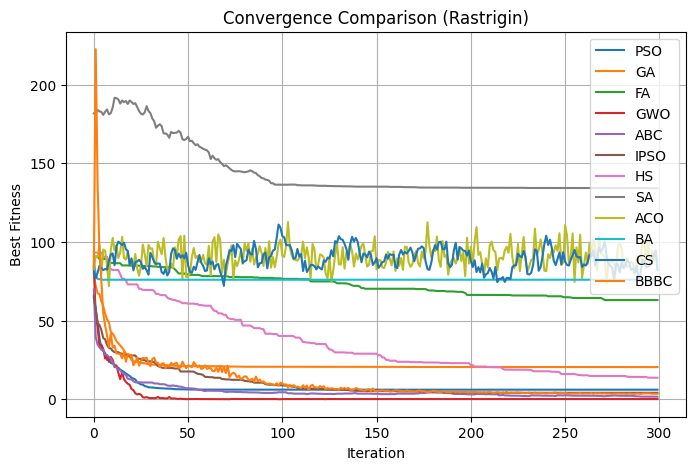

In [ ]:
plt.figure(figsize=(8,5))
for a in algorithms:
    plt.plot(results["Rastrigin"][a]["AvgCurve"], label=a)
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison (Rastrigin)")
plt.legend()
plt.grid(True)
plt.show()

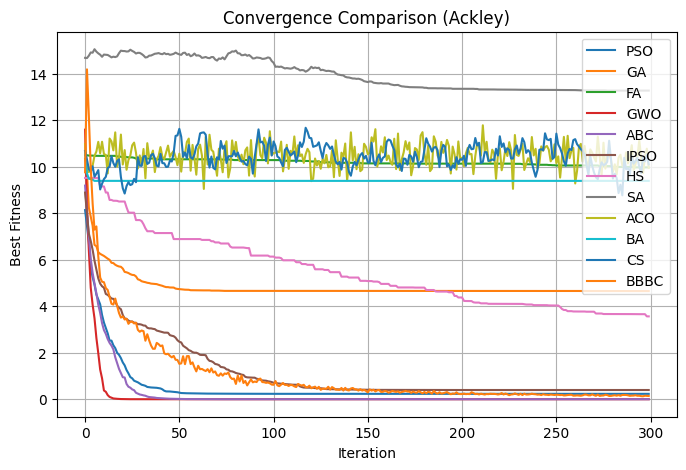

In [ ]:
plt.figure(figsize=(8,5))
for a in algorithms:
    plt.plot(results["Ackley"][a]["AvgCurve"], label=a)
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison (Ackley)")
plt.legend()
plt.grid(True)
plt.show()

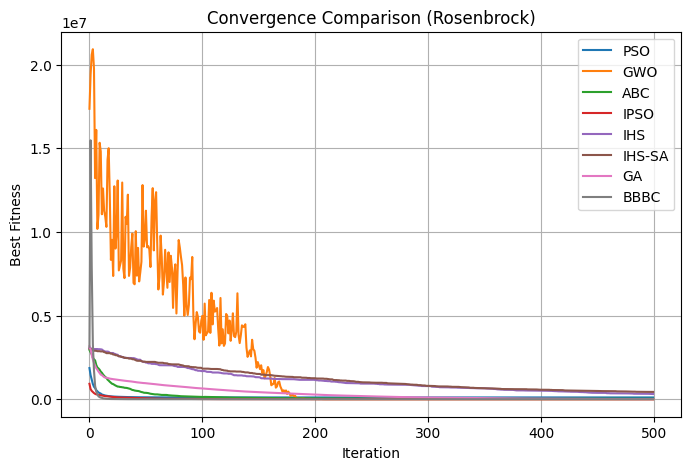

In [ ]:
plt.figure(figsize=(8,5))
for a in algorithms:
    plt.plot(results["Rosenbrock"][a]["AvgCurve"], label=a)
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison (Rosenbrock)")
plt.legend()
plt.grid(True)
plt.show()

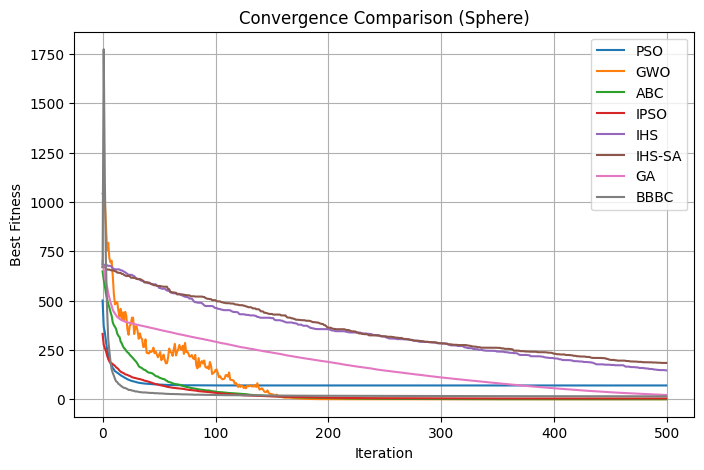

In [ ]:
plt.figure(figsize=(8,5))
for a in algorithms:
    plt.plot(results["Sphere"][a]["AvgCurve"], label=a)
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison (Sphere)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

In [ ]:
ranking_table = []

for f in results:

    algos = list(results[f].keys())

    mean_vals = [results[f][a]["Mean"] for a in algos]
    cv_vals   = [results[f][a]["CV"] for a in algos]
    conv_vals = [avg_conv_iter(results[f][a]["AvgCurve"]) for a in algos]
    time_vals = [results[f][a]["AvgTime"] for a in algos]

    # Normalize (all lower-is-better)
    mean_n = normalize(mean_vals)
    cv_n   = normalize(cv_vals)
    conv_n = normalize(conv_vals)
    time_n = normalize(time_vals)

    # Weighted score (you can adjust weights if needed)
    score = (
        0.4 * mean_n +
        0.3 * cv_n +
        0.2 * conv_n +
        0.1 * time_n
    )

    for i, a in enumerate(algos):
        ranking_table.append([
            f,
            a,
            mean_vals[i],
            cv_vals[i],
            conv_vals[i],
            time_vals[i],
            score[i]
        ])

In [ ]:
df_ranking = pd.DataFrame(
    ranking_table,
    columns=[
        "Function",
        "Algorithm",
        "Mean Fitness",
        "CV",
        "Avg Convergence Iter",
        "Avg CPU Time (s)",
        "Overall Score"
    ]
)

# Rank (lower score = better)
df_ranking["Rank"] = df_ranking.groupby("Function")["Overall Score"] \
                                .rank(method="dense")

df_ranking.sort_values(["Function", "Rank"])

,Function,Algorithm,Mean Fitness,CV,Avg Convergence Iter,Avg CPU Time (s),Overall Score,Rank
18,Ackley,ABC,1.206757e-01,0.300115,165,2.975460,0.263248,1.0
20,Ackley,IHS,8.757315e+00,0.050957,4,0.109557,0.336092,2.0
21,Ackley,IHS-SA,9.693332e+00,0.045138,11,0.158195,0.374166,3.0
19,Ackley,IPSO,3.181246e+00,0.234008,490,0.718270,0.407948,4.0
16,Ackley,PSO,7.848457e+00,0.175454,199,0.414975,0.436483,5.0
17,Ackley,GWO,1.313024e-13,0.861264,264,1.680530,0.459655,6.0
22,Ackley,GA,1.048929e+01,0.075398,127,0.595916,0.477690,7.0
23,Ackley,BBBC,8.258002e+00,0.129510,500,0.421602,0.556814,8.0
8,Rastrigin,PSO,3.046473e+02,0.303824,240,0.211517,NaN,NaN
9,Rastrigin,GWO,0.000000e+00,NaN,296,1.471350,NaN,NaN
